In [36]:
# CELL 1 — INSTALL DEPENDENCIES

!pip install ultralytics --quiet

In [37]:
# CELL 2 — IMPORTS

import os
import pandas as pd
from PIL import Image
from ultralytics import YOLO
from tqdm import tqdm
import matplotlib.pyplot as plt
import shutil

In [38]:
print(os.listdir("/kaggle/input/datasets/mithilesh2303/deepfashion/In-shop Clothes Retrieval Benchmark"))

['README.txt', 'Eval', 'Img', 'Anno']


In [30]:
import os

base = "/kaggle/input/datasets/mithilesh2303/deepfashion/In-shop Clothes Retrieval Benchmark/Img"

print(os.listdir(base))
print(os.listdir(base + "/img")[:5])

['img']
['img']


In [58]:
# CELL 3 — DATASET PATHS

DATASET_PATH = "/kaggle/input/datasets/mithilesh2303/deepfashion/In-shop Clothes Retrieval Benchmark"


EVAL_FILE = os.path.join(
    DATASET_PATH,
    "Eval",
    "list_eval_partition.txt"
)

OUTPUT_DIR = "/kaggle/working/cropped_images"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset paths ready.")

Dataset paths ready.


In [94]:
data = []

with open(EVAL_FILE, "r") as f:
    lines = f.readlines()

for line in lines[2:]:

    parts = line.strip().split()

    image_relative_path = parts[0]
    item_id = parts[1]
    split = parts[2]

    # Correct path with DOUBLE img folder
    full_image_path = os.path.join(
        DATASET_PATH,
        "Img",
        "img",
        image_relative_path
    )

    data.append({
        "image_path": full_image_path,
        "relative_path": image_relative_path,
        "item_id": item_id,
        "split": split
    })

df = pd.DataFrame(data)

print(df.head())

                                          image_path  \
0  /kaggle/input/datasets/mithilesh2303/deepfashi...   
1  /kaggle/input/datasets/mithilesh2303/deepfashi...   
2  /kaggle/input/datasets/mithilesh2303/deepfashi...   
3  /kaggle/input/datasets/mithilesh2303/deepfashi...   
4  /kaggle/input/datasets/mithilesh2303/deepfashi...   

                                       relative_path      item_id  split  
0       img/WOMEN/Dresses/id_00000002/02_1_front.jpg  id_00000002  train  
1        img/WOMEN/Dresses/id_00000002/02_2_side.jpg  id_00000002  train  
2        img/WOMEN/Dresses/id_00000002/02_4_full.jpg  id_00000002  train  
3  img/WOMEN/Dresses/id_00000002/02_7_additional.jpg  id_00000002  train  
4        img/WOMEN/Skirts/id_00000003/02_1_front.jpg  id_00000003  train  


In [95]:
print(df.iloc[0]["image_path"])

/kaggle/input/datasets/mithilesh2303/deepfashion/In-shop Clothes Retrieval Benchmark/Img/img/img/WOMEN/Dresses/id_00000002/02_1_front.jpg


In [96]:
import os

sample_path = df.iloc[0]["image_path"]

print(sample_path)

print(os.path.exists(sample_path))

/kaggle/input/datasets/mithilesh2303/deepfashion/In-shop Clothes Retrieval Benchmark/Img/img/img/WOMEN/Dresses/id_00000002/02_1_front.jpg
True


In [97]:
# CELL 5 — USE SMALL SUBSET FIRST

# START SMALL FOR TESTING
# Later change 500 → 3000 or 5000

#df = df.sample(3000, random_state=42).reset_index(drop=True)

print("Images selected:", len(df))

Images selected: 52712


In [98]:
# CELL 6 — LOAD YOLO MODEL

model = YOLO("yolov8n.pt")

print("YOLO model loaded.")

YOLO model loaded.



image 1/1 /kaggle/input/datasets/mithilesh2303/deepfashion/In-shop Clothes Retrieval Benchmark/Img/img/img/WOMEN/Dresses/id_00000002/02_1_front.jpg: 640x640 1 person, 7.7ms
Speed: 2.1ms preprocess, 7.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


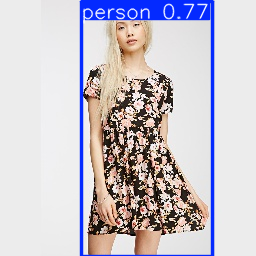

In [99]:
# CELL 7 — TEST YOLO ON SINGLE IMAGE

sample_path = df.iloc[0]["image_path"]

results = model(sample_path)

results[0].show()

In [100]:
import shutil
import os

# delete old cropped_images folder completely
shutil.rmtree("/kaggle/working/cropped_images", ignore_errors=True)

# recreate empty folder
os.makedirs("/kaggle/working/cropped_images", exist_ok=True)

print("Old cropped images removed.")

Old cropped images removed.


In [101]:
from tqdm import tqdm

failed = []

batch_size = 500

total_images = len(df)

for start in range(0, total_images, batch_size):

    end = min(start + batch_size, total_images)

    batch_df = df.iloc[start:end]

    print(f"\nProcessing batch {start} to {end}")

    for idx, row in tqdm(batch_df.iterrows(), total=len(batch_df)):

        img_path = row["image_path"]

        try:

            image = Image.open(img_path).convert("RGB")

            results = model(image, verbose=False)

            boxes = results[0].boxes

            if len(boxes) > 0:

                box = boxes[0].xyxy[0].tolist()

                x1, y1, x2, y2 = map(int, box)

                cropped = image.crop((x1, y1, x2, y2))

            else:

                cropped = image

            save_name = row["relative_path"].replace("/", "_")

            save_path = os.path.join(
                OUTPUT_DIR,
                save_name
            )

            cropped.save(save_path)

        except Exception as e:

            failed.append((img_path, str(e)))

    print(f"Completed batch {start} to {end}")

print("All batches complete.")
print("Failed images:", len(failed))


Processing batch 0 to 500


100%|██████████| 500/500 [00:07<00:00, 67.72it/s]


Completed batch 0 to 500

Processing batch 500 to 1000


100%|██████████| 500/500 [00:07<00:00, 67.08it/s]


Completed batch 500 to 1000

Processing batch 1000 to 1500


...

Completed batch 51500 to 52000

Processing batch 52000 to 52500


100%|██████████| 500/500 [00:09<00:00, 54.69it/s]


Completed batch 52000 to 52500

Processing batch 52500 to 52712


100%|██████████| 212/212 [00:03<00:00, 54.31it/s]

Completed batch 52500 to 52712
All batches complete.
Failed images: 0


In [102]:
len(os.listdir(OUTPUT_DIR))

52712

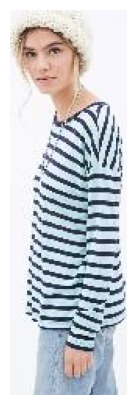

In [103]:
# CELL 9 — VISUALIZE CROPPED IMAGE

sample_crop = os.listdir(OUTPUT_DIR)[0]

img = Image.open(
    os.path.join(OUTPUT_DIR, sample_crop)
)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [104]:
# CELL 10 — CREATE CROPPED METADATA CSV

cropped_data = []

for idx, row in df.iterrows():

    cropped_name = os.path.basename(
        row["image_path"]
    )

    cropped_path = os.path.join(
        OUTPUT_DIR,
        cropped_name
    )

    cropped_data.append({
        "cropped_image_path": cropped_path,
        "item_id": row["item_id"],
        "split": row["split"]
    })

cropped_df = pd.DataFrame(cropped_data)

cropped_df.to_csv(
    "/kaggle/working/cropped_metadata.csv",
    index=False
)

print(cropped_df.head())

                                  cropped_image_path      item_id  split
0      /kaggle/working/cropped_images/02_1_front.jpg  id_00000002  train
1       /kaggle/working/cropped_images/02_2_side.jpg  id_00000002  train
2       /kaggle/working/cropped_images/02_4_full.jpg  id_00000002  train
3  /kaggle/working/cropped_images/02_7_additional...  id_00000002  train
4      /kaggle/working/cropped_images/02_1_front.jpg  id_00000003  train


In [105]:
# CELL 11 — OPTIONAL: CHECK FAILED IMAGES

print(failed[:10])

[]


In [106]:
import shutil
import os

# Remove old final_dataset folder
shutil.rmtree("/kaggle/working/final_dataset", ignore_errors=True)

# Remove old zip file
zip_path = "/kaggle/working/processed_dataset.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

print("Old final_dataset and ZIP removed.")

Old final_dataset and ZIP removed.


In [107]:
import os
import shutil

FINAL_DIR = "/kaggle/working/final_dataset"

os.makedirs(FINAL_DIR, exist_ok=True)

print("Final folder created.")

Final folder created.


In [108]:
shutil.copy(
    "/kaggle/working/cropped_metadata.csv",
    FINAL_DIR
)

shutil.copy(
    "/kaggle/working/all_metadata.csv",
    FINAL_DIR
)

shutil.copytree(
    "/kaggle/working/cropped_images",
    os.path.join(FINAL_DIR, "cropped_images"),
    dirs_exist_ok=True
)

print("Required files copied.")

Required files copied.


In [110]:
zip_path = "/kaggle/working/final_dataset.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

In [90]:
# CELL 13 — CHECK FINAL OUTPUT FILES

os.listdir("/kaggle/working")

['cropped_images',
 '.virtual_documents',
 'cropped_metadata.csv',
 'all_metadata.csv',
 'final_dataset',
 'yolov8n.pt']

In [112]:
shutil.make_archive(
    "/kaggle/working/final_dataset",
    'zip',
    FINAL_DIR
)

print("ZIP created successfully.")

ZIP created successfully.


In [113]:
zip_path = "/kaggle/working/final_dataset.zip"

size_gb = os.path.getsize(zip_path) / (1024**2)

print(f"ZIP size: {size_gb:.2f} MB")

ZIP size: 324.32 MB


In [111]:
len(os.listdir(OUTPUT_DIR))

52712